In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
V_228 = pd.read_csv('../dataset/PeMSD7/V_228.csv')
V_1026 = pd.read_csv('../dataset/PeMSD7/V_1026.csv')
traffic_228_2d = V_228.values
traffic_1026_2d = V_1026.values

shanghai_data = pd.read_csv('../dataset/ShanghaiRailway/V_43.csv', header=None)
shanghai_2d = shanghai_data.values

air_quality_data = np.load('../dataset/AirQuality/air_quality_data.npy')
air_quality_data_2d = air_quality_data.reshape(air_quality_data.shape[0], -1)


datasets_dict = {
    'PeMSD7 (228 Nodes)': traffic_228_2d,
    'PeMSD7 (1026 Nodes)': traffic_1026_2d,
    'Shanghai Railway (43 Nodes)': shanghai_2d,
    'Beijing Air Quality': air_quality_data_2d
}

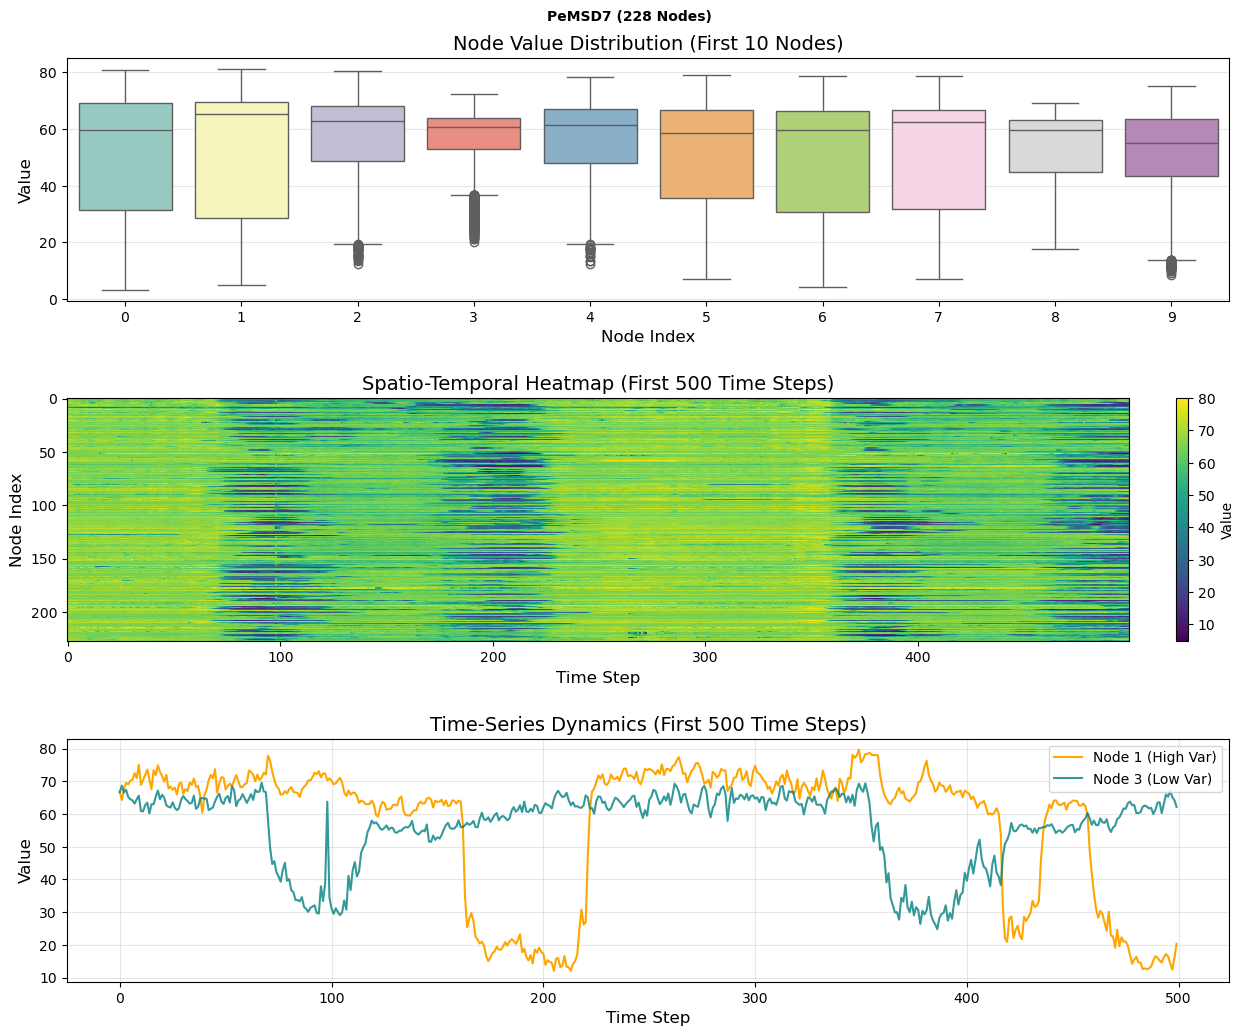

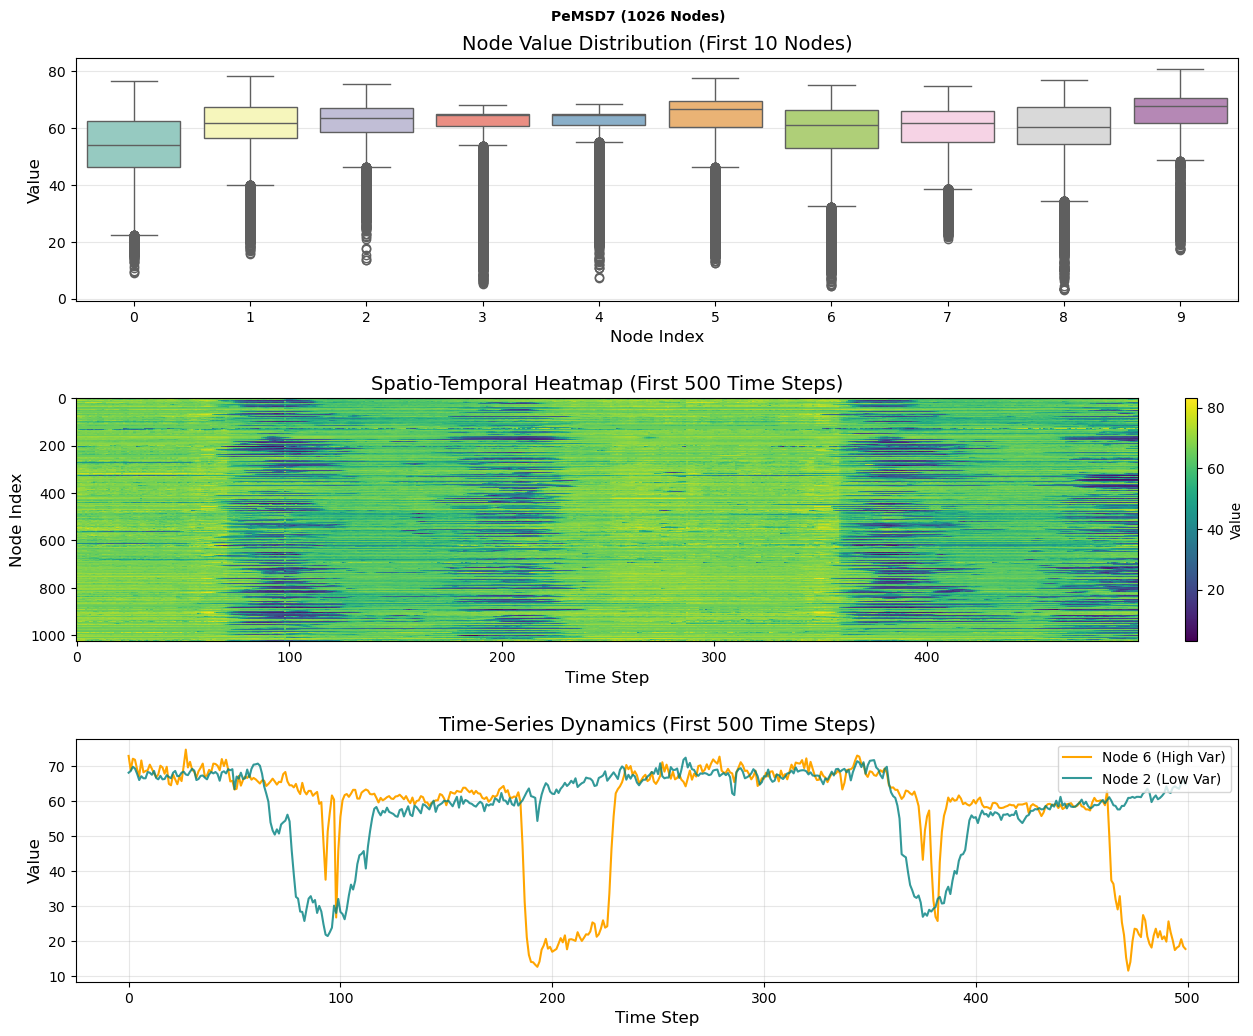

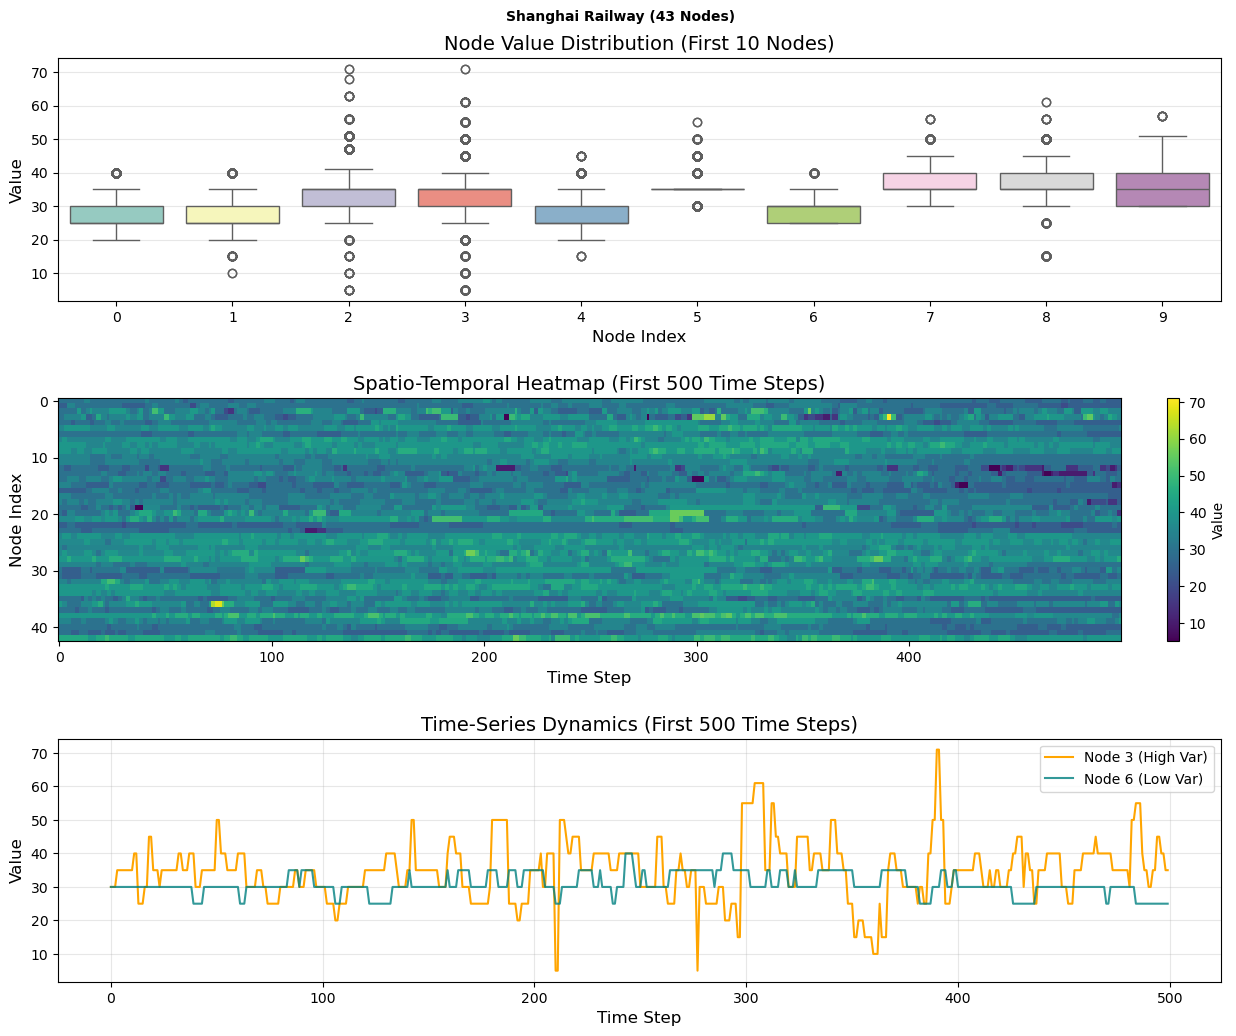

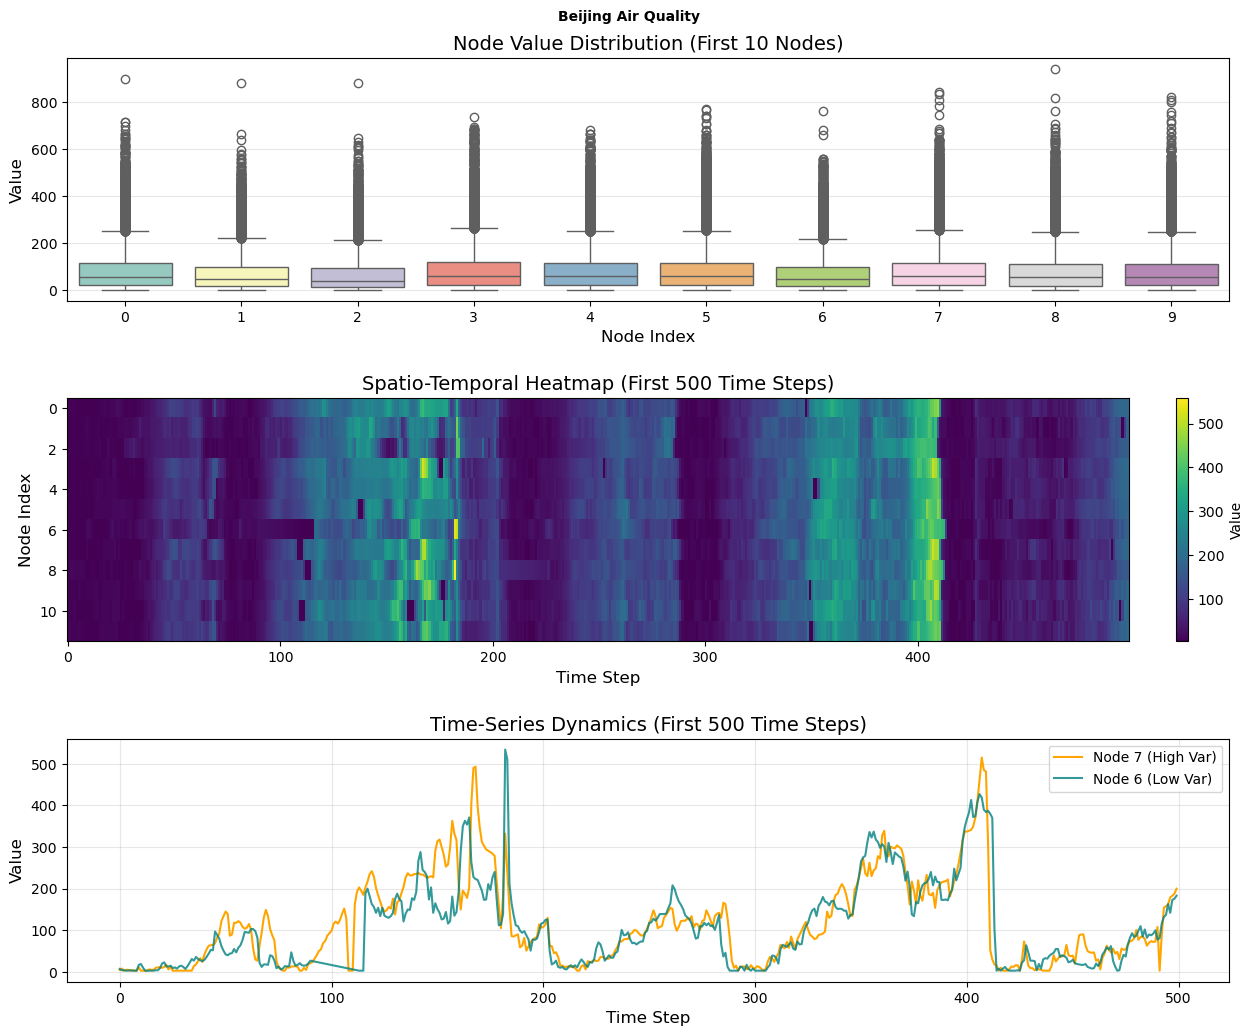

In [4]:
def plot_comprehensive_eda(dataset_name, data_2d):
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    fig.suptitle(f'{dataset_name}', fontsize=10, fontweight='bold', y=0.92)
    
    num_nodes_to_plot = min(10, data_2d.shape[1])
    
    # Boxplot
    sns.boxplot(data=data_2d[:, :num_nodes_to_plot], palette="Set3", ax=axes[0])
    axes[0].set_title(f'Node Value Distribution (First {num_nodes_to_plot} Nodes)', fontsize=14)
    axes[0].set_xlabel('Node Index', fontsize=12)
    axes[0].set_ylabel('Value', fontsize=12)
    axes[0].grid(True, alpha=0.3, axis='y')

    #  Spatio-Temporal Heatmap
    time_slice_heatmap = min(500, data_2d.shape[0])
    heatmap_data = data_2d[:time_slice_heatmap, :].T
    
    im = axes[1].imshow(heatmap_data, aspect='auto', cmap='viridis', interpolation='nearest')
    axes[1].set_title(f'Spatio-Temporal Heatmap (First {time_slice_heatmap} Time Steps)', fontsize=14)
    axes[1].set_xlabel('Time Step', fontsize=12)
    axes[1].set_ylabel('Node Index', fontsize=12)
    fig.colorbar(im, ax=axes[1], label='Value', fraction=0.046, pad=0.04)
    
    # Time-Series Dynamics
    time_slice_series = min(500, data_2d.shape[0])
    std_devs = np.std(data_2d[:, :num_nodes_to_plot], axis=0)
    node_high_var = np.argmax(std_devs)
    node_low_var = np.argmin(std_devs)
    
    axes[2].plot(data_2d[:time_slice_series, node_high_var], label=f'Node {node_high_var} (High Var)', color='orange', linewidth=1.5)
    axes[2].plot(data_2d[:time_slice_series, node_low_var], label=f'Node {node_low_var} (Low Var)', color='teal', linewidth=1.5, alpha=0.8)
    axes[2].set_title(f'Time-Series Dynamics (First {time_slice_series} Time Steps)', fontsize=14)
    axes[2].set_xlabel('Time Step', fontsize=12)
    axes[2].set_ylabel('Value', fontsize=12)
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    
    plt.subplots_adjust(hspace=0.4)
    # save
    plt.savefig(f'EDA_{dataset_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

for name, data in datasets_dict.items():
    plot_comprehensive_eda(name, data)